In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [3]:
NUM_CLASSES = 20

# Dataset reading

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │           860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           220 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290 (5.04 KB)

 Trainable params: 1,290 (5.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [11]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
 1/23 ━━━━━━━━━━━━━━━━━━━━ 9s 430ms/step - accuracy: 0.0156 - loss: 3.2097
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0282 - loss: 3.1016 - val_accuracy: 0.1726 - val_loss: 2.9042
Epoch 2/1000
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0938 - loss: 2.9365
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1024 - loss: 2.8933 - val_accuracy: 0.2663 - val_loss: 2.6868
Epoch 3/1000
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1875 - loss: 2.7464
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2171 - loss: 2.6571 - val_accuracy: 0.4053 - val_loss: 2.3498
Epoch 4/1000
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2812 - loss: 2.4320
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier.keras
2

In [12]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9823 - loss: 0.1437 


In [13]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [14]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[9.9182433e-01 6.5721395e-07 8.1727281e-03 3.2995537e-10 3.1192109e-09
 2.3054622e-06 2.1829003e-12 7.9435471e-17 1.2838570e-14 3.7014472e-14
 3.1915984e-16 3.0015250e-16 3.2394716e-17 1.3903021e-15 2.6892976e-16
 7.0471633e-15 8.2571821e-16 1.1397448e-18 6.0861515e-13 3.9193949e-13]
0


# Confusion matrix

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step


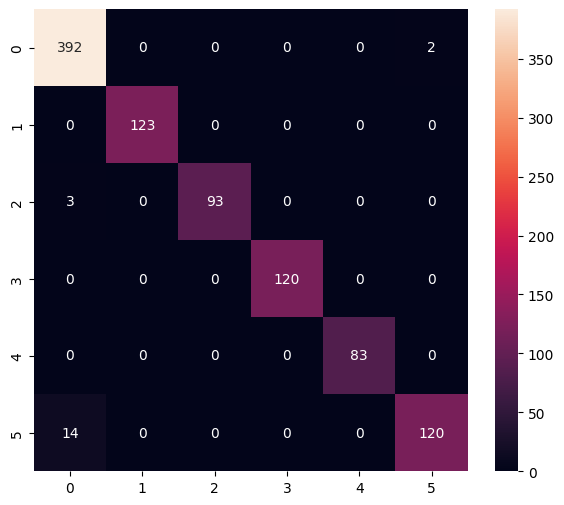

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       394
           1       1.00      1.00      1.00       123
           2       1.00      0.97      0.98        96
           3       1.00      1.00      1.00       120
           4       1.00      1.00      1.00        83
           5       0.98      0.90      0.94       134

    accuracy                           0.98       950
   macro avg       0.99      0.98      0.98       950
weighted avg       0.98      0.98      0.98       950



In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [16]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [17]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /var/folders/4r/cmp5svvs0jn_x9cpj78ddj800000gn/T/tmpbxu1dmx8/assets


INFO:tensorflow:Assets written to: /var/folders/4r/cmp5svvs0jn_x9cpj78ddj800000gn/T/tmpbxu1dmx8/assets


Saved artifact at '/var/folders/4r/cmp5svvs0jn_x9cpj78ddj800000gn/T/tmpbxu1dmx8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  13053231568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13053240016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13053233296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13053238480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13053240592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13053236368: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1740326457.703788  484749 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1740326457.704446  484749 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1740326457.708886  484749 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


7260

# Inference test

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [19]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [20]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [21]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 118 μs, sys: 48 μs, total: 166 μs
Wall time: 145 μs


In [22]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[9.9182433e-01 6.5721525e-07 8.1727365e-03 3.2995479e-10 3.1192111e-09
 2.3054599e-06 2.1829006e-12 7.9435478e-17 1.2838571e-14 3.7014479e-14
 3.1916111e-16 3.0015142e-16 3.2394719e-17 1.3903024e-15 2.6892981e-16
 7.0471642e-15 8.2572149e-16 1.1397450e-18 6.0861521e-13 3.9193952e-13]
0
